Settaggio ambiente

In [8]:
!pip install pandas numpy matplotlib seaborn plotly sqlalchemy openpyxl sqlite3

import os
import pandas as pd
import requests
import sqlite3
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3

[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Struttura cartelle progetto

In [9]:
project_path = os.path.join(os.path.expanduser("~"), "Desktop", "portfolio_demografico")

for folder in ['data/raw', 'data/processed', 'outputs/charts', 'outputs/sql']:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

os.chdir(project_path)
print("Cartella di lavoro:", os.getcwd())

Cartella di lavoro: C:\Users\maria\Desktop\portfolio_demografico


Acquisizione dati

In [10]:
def get_worldbank_data(indicator, country_list, start_year=2000, end_year=2022):
    countries = ";".join(country_list)
    url = f"https://api.worldbank.org/v2/country/{countries}/indicator/{indicator}?date={start_year}:{end_year}&format=json&per_page=1000"
    r = requests.get(url)
    data = r.json()[1]
    df = pd.DataFrame([{
        "country": d["country"]["value"],
        "year": int(d["date"]),
        "value": d["value"]
    } for d in data if d["value"] is not None])
    return df

# Paesi EU principali
eu_countries = ["ITA","DEU","FRA","ESP","POL","NLD","BEL","SWE","AUT","PRT","GRC","HUN","CZE","ROU","FIN","DNK"]

# Scarica i 3 indicatori
print("Scarico dati...")

# 1. Popolazione over 65 (% sul totale)
pop65 = get_worldbank_data("SP.POP.65UP.TO.ZS", eu_countries)
pop65.to_csv("data/raw/pop65.csv", index=False)
print(f"✓ Pop65: {pop65.shape[0]} righe")

# 2. Spesa sanitaria pro capite (USD)
health_exp = get_worldbank_data("SH.XPD.CHEX.PC.CD", eu_countries)
health_exp.to_csv("data/raw/health_expenditure.csv", index=False)
print(f"✓ Spesa sanitaria: {health_exp.shape[0]} righe")

# 3. Aspettativa di vita
life_exp = get_worldbank_data("SP.DYN.LE00.IN", eu_countries)
life_exp.to_csv("data/raw/life_expectancy.csv", index=False)
print(f"✓ Aspettativa di vita: {life_exp.shape[0]} righe")

print("\nTutti i dataset scaricati e salvati in data/raw/ ✓")

Scarico dati...
✓ Pop65: 368 righe
✓ Spesa sanitaria: 368 righe
✓ Aspettativa di vita: 368 righe

Tutti i dataset scaricati e salvati in data/raw/ ✓


Creazione del DB SQL

In [11]:
pop65 = pd.read_csv("data/raw/pop65.csv")
health_exp = pd.read_csv("data/raw/health_expenditure.csv")
life_exp = pd.read_csv("data/raw/life_expectancy.csv")

pop65 = pop65.rename(columns={"value": "pop65_percentage"})
health_exp = health_exp.rename(columns={"value": "health_exp_usd"})
life_exp = life_exp.rename(columns={"value": "life_expectancy"})

conn = sqlite3.connect("outputs/sql/portfolio.db")

pop65.to_sql("population_65", conn, if_exists="replace", index=False)
health_exp.to_sql("health_expenditure", conn, if_exists="replace", index=False)
life_exp.to_sql("life_expectancy", conn, if_exists="replace", index=False)

print("✓ Database creato con 3 tabelle:")
print("  - population_65")
print("  - health_expenditure")
print("  - life_expectancy")

conn.close()

✓ Database creato con 3 tabelle:
  - population_65
  - health_expenditure
  - life_expectancy


Grafici

In [13]:
os.chdir(r"C:\Users\maria\Desktop\portfolio_demografico")

conn = sqlite3.connect("outputs/sql/portfolio.db")

df = pd.read_sql("""
    SELECT 
        p.country, p.year,
        p.pop65_percentage,
        l.life_expectancy,
        h.health_exp_usd
    FROM population_65 p
    JOIN life_expectancy l ON p.country = l.country AND p.year = l.year
    JOIN health_expenditure h ON p.country = h.country AND p.year = h.year
""", conn)

conn.close()

df_efficienza = pd.read_csv("outputs/sql/query_efficienza.csv")
df_velocita = pd.read_csv("outputs/sql/query_velocita.csv")
df_proiezioni = pd.read_csv("outputs/sql/query_proiezioni.csv")

print(f"✓ Dataset completo: {df.shape[0]} righe")
print(f"✓ Efficienza: {df_efficienza.shape[0]} paesi")
print(f"✓ Velocità: {df_velocita.shape[0]} paesi")
print(f"✓ Proiezioni: {df_proiezioni.shape[0]} paesi")

✓ Dataset completo: 368 righe
✓ Efficienza: 16 paesi
✓ Velocità: 16 paesi
✓ Proiezioni: 16 paesi


Grafici dei risultati

In [14]:
sns.set_theme(style="whitegrid", palette="muted")
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['axes.titleweight'] = 'bold'

print("✓ Stile configurato")

✓ Stile configurato


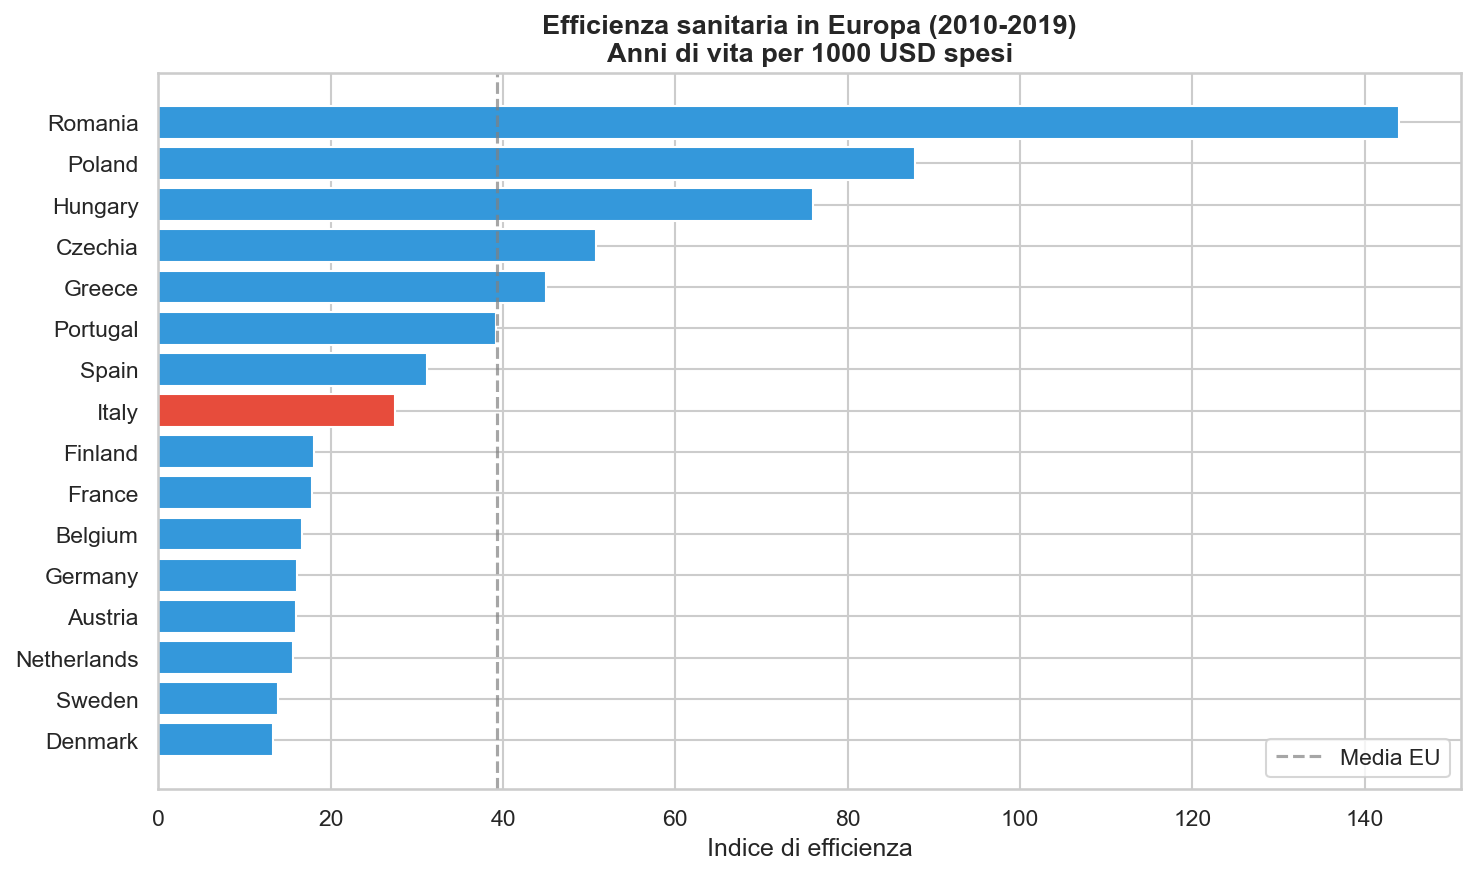

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
df_eff = df_efficienza.sort_values('indice_efficienza')
colors = ['#e74c3c' if c == 'Italy' else '#3498db' for c in df_eff['country']]
ax.barh(df_eff['country'], df_eff['indice_efficienza'], color=colors)
ax.axvline(x=df_eff['indice_efficienza'].mean(), color='gray', linestyle='--', alpha=0.7, label='Media EU')
ax.set_title("Efficienza sanitaria in Europa (2010-2019)\nAnni di vita per 1000 USD spesi")
ax.set_xlabel("Indice di efficienza")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/charts/01_efficienza_sanitaria.png", bbox_inches='tight')
plt.show()

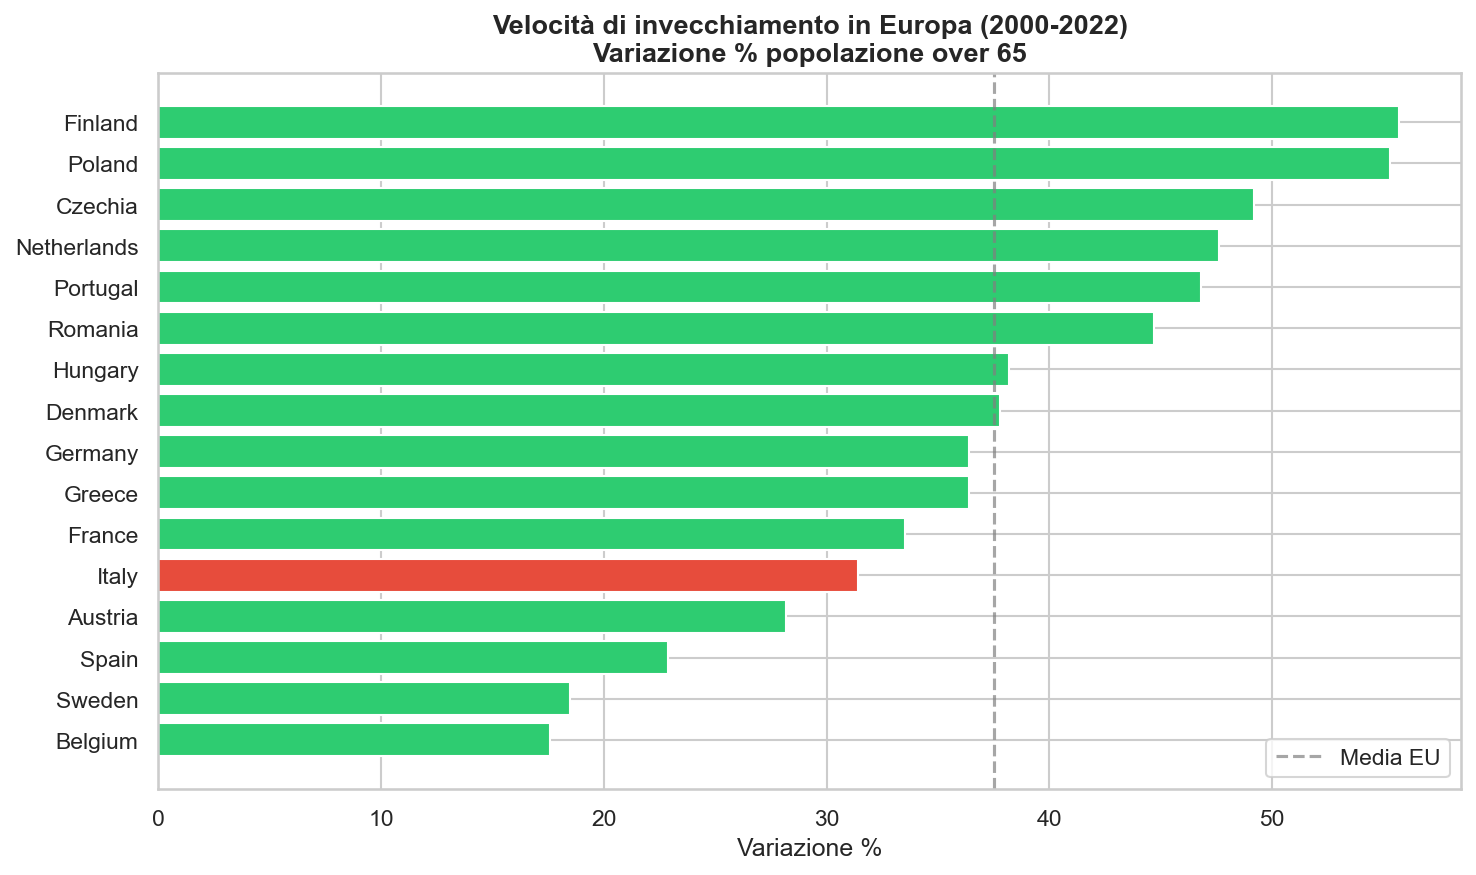

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
df_vel = df_velocita.sort_values('variazione_percentage')
colors = ['#e74c3c' if c == 'Italy' else '#2ecc71' for c in df_vel['country']]
ax.barh(df_vel['country'], df_vel['variazione_percentage'], color=colors)
ax.axvline(x=df_vel['variazione_percentage'].mean(), color='gray', linestyle='--', alpha=0.7, label='Media EU')
ax.set_title("Velocità di invecchiamento in Europa (2000-2022)\nVariazione % popolazione over 65")
ax.set_xlabel("Variazione %")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/charts/02_velocita_invecchiamento.png", bbox_inches='tight')
plt.show()

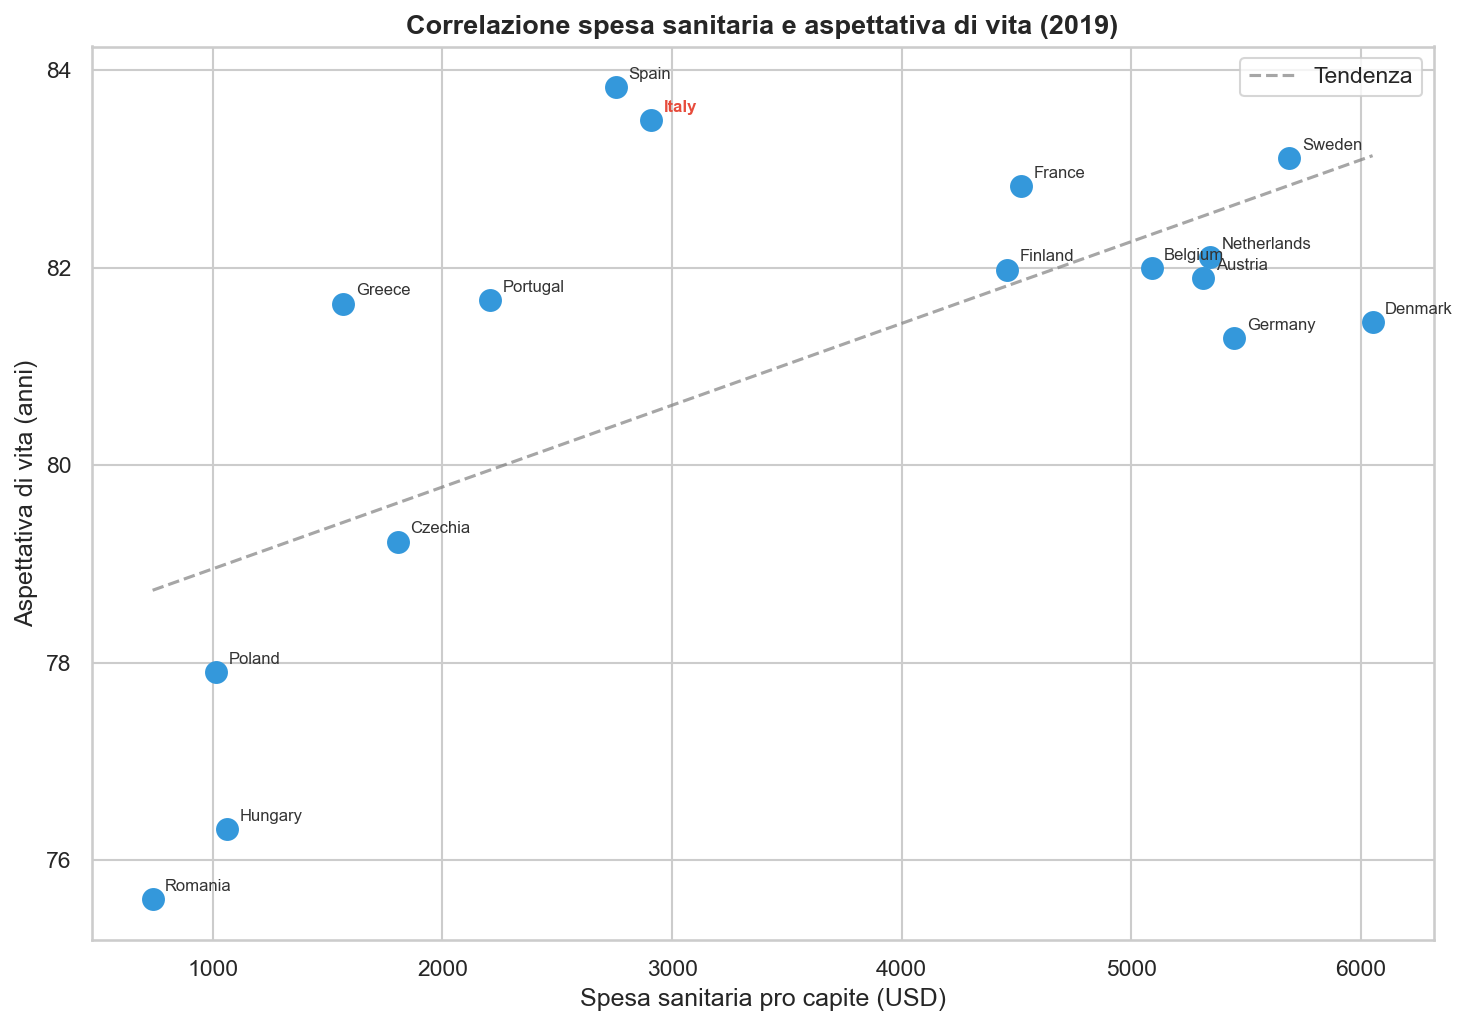

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
df_2019 = df[df['year'] == 2019].copy()
ax.scatter(df_2019['health_exp_usd'], df_2019['life_expectancy'], 
           color='#3498db', s=100, zorder=3)
for _, row in df_2019.iterrows():
    color = '#e74c3c' if row['country'] == 'Italy' else '#333333'
    weight = 'bold' if row['country'] == 'Italy' else 'normal'
    ax.annotate(row['country'], (row['health_exp_usd'], row['life_expectancy']),
                textcoords="offset points", xytext=(6, 4), fontsize=8,
                color=color, fontweight=weight)

# Linea di tendenza
import numpy as np
z = np.polyfit(df_2019['health_exp_usd'], df_2019['life_expectancy'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_2019['health_exp_usd'].min(), df_2019['health_exp_usd'].max(), 100)
ax.plot(x_line, p(x_line), color='gray', linestyle='--', alpha=0.7, label='Tendenza')

ax.set_title("Correlazione spesa sanitaria e aspettativa di vita (2019)")
ax.set_xlabel("Spesa sanitaria pro capite (USD)")
ax.set_ylabel("Aspettativa di vita (anni)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/charts/03_correlazione.png", bbox_inches='tight')
plt.show()

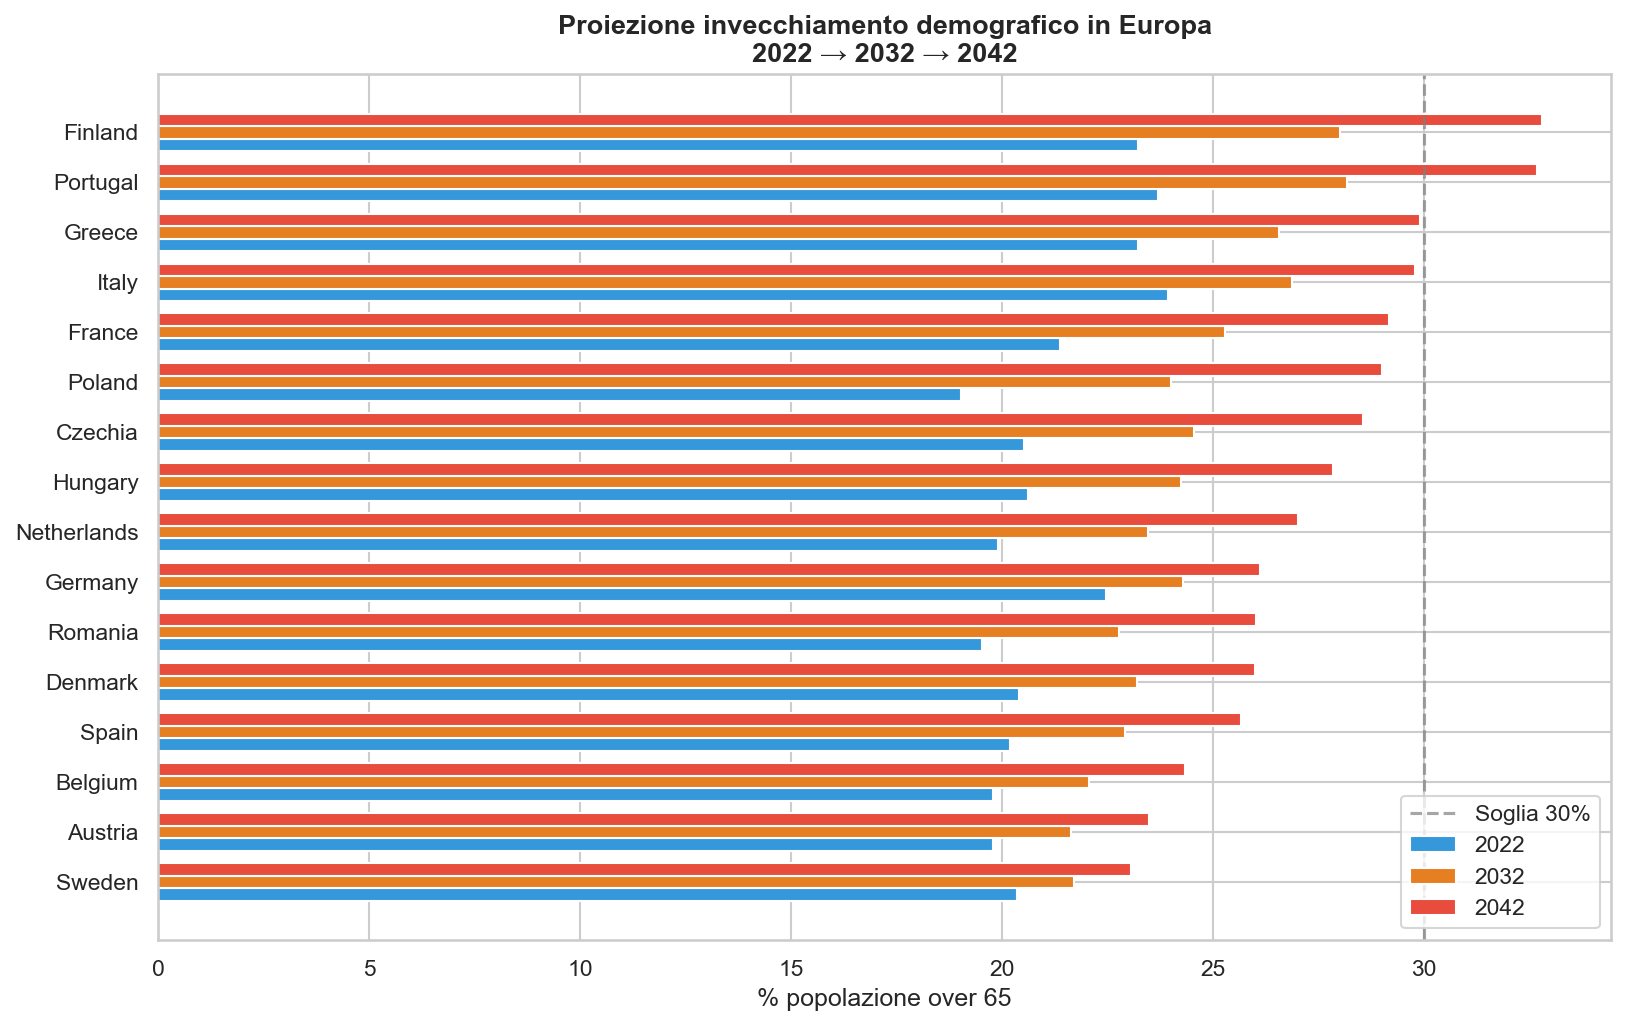

In [18]:
fig, ax = plt.subplots(figsize=(11, 7))
df_proj = df_proiezioni.sort_values('proiezione_2042', ascending=True)
x = range(len(df_proj))
width = 0.25

bars1 = ax.barh([i - width for i in x], df_proj['percentage_2022'], width, label='2022', color='#3498db')
bars2 = ax.barh([i for i in x], df_proj['proiezione_2032'], width, label='2032', color='#e67e22')
bars3 = ax.barh([i + width for i in x], df_proj['proiezione_2042'], width, label='2042', color='#e74c3c')

ax.set_yticks(list(x))
ax.set_yticklabels(df_proj['country'])
ax.axvline(x=30, color='gray', linestyle='--', alpha=0.7, label='Soglia 30%')
ax.set_title("Proiezione invecchiamento demografico in Europa\n2022 → 2032 → 2042")
ax.set_xlabel("% popolazione over 65")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/charts/04_proiezioni.png", bbox_inches='tight')
plt.show()

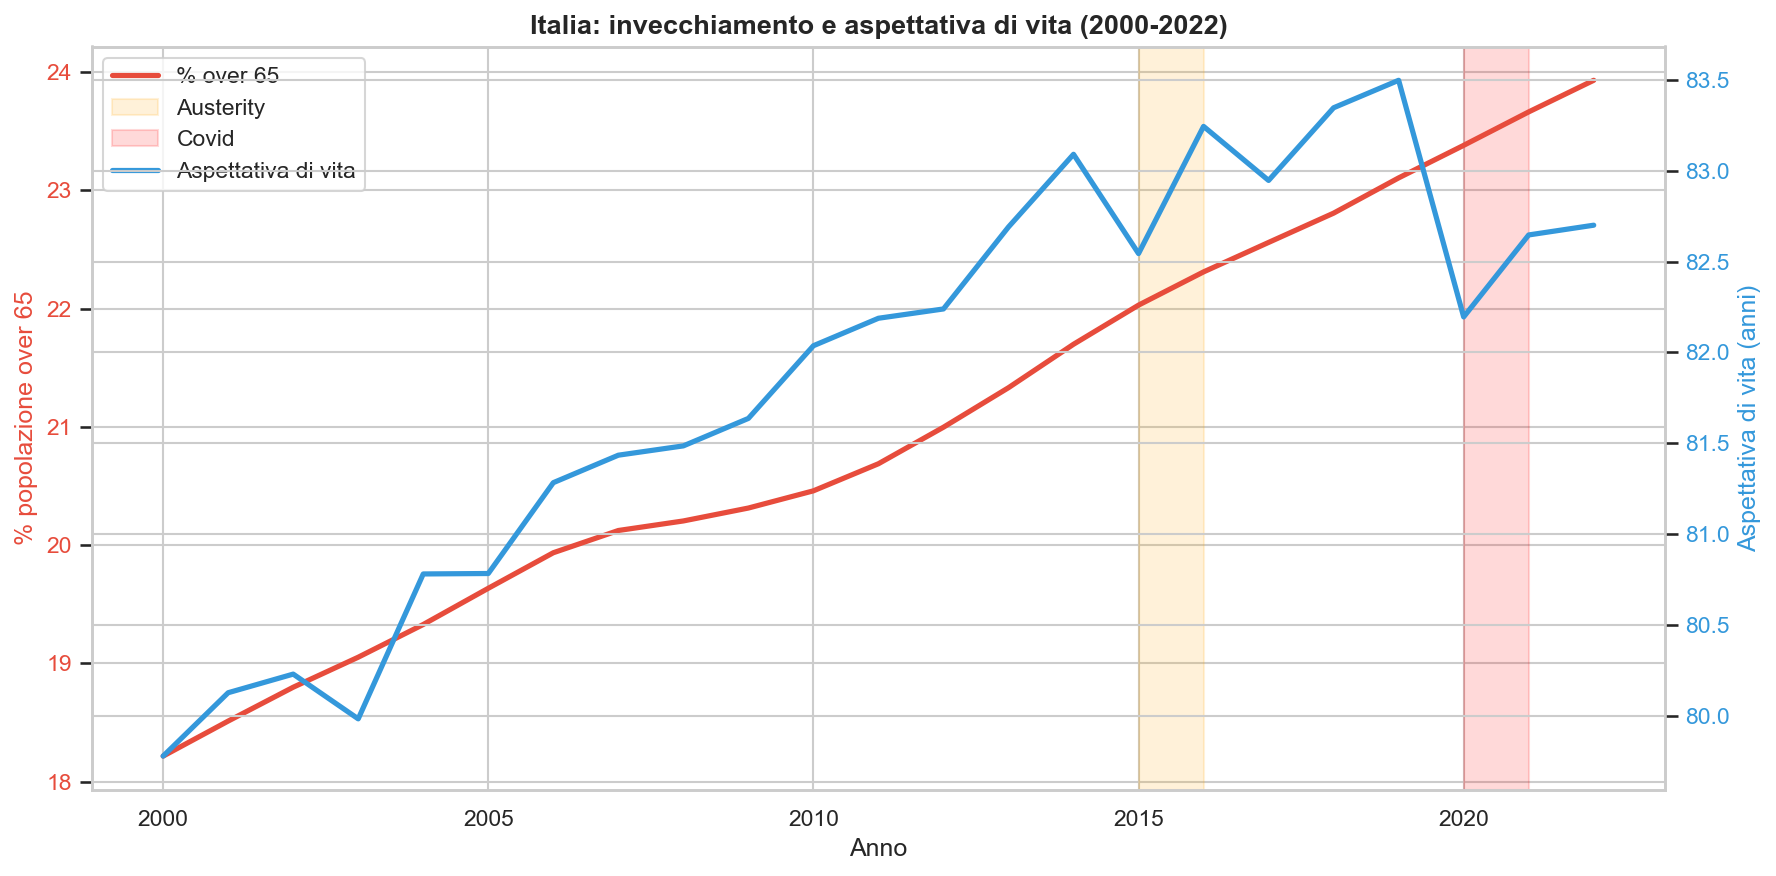

In [19]:
fig, ax1 = plt.subplots(figsize=(12, 6))

df_ita = df[df['country'] == 'Italy'].sort_values('year')

ax1.plot(df_ita['year'], df_ita['pop65_percentage'], color='#e74c3c', linewidth=2.5, label='% over 65')
ax1.set_xlabel("Anno")
ax1.set_ylabel("% popolazione over 65", color='#e74c3c')
ax1.tick_params(axis='y', labelcolor='#e74c3c')

ax2 = ax1.twinx()
ax2.plot(df_ita['year'], df_ita['life_expectancy'], color='#3498db', linewidth=2.5, label='Aspettativa di vita')
ax2.set_ylabel("Aspettativa di vita (anni)", color='#3498db')
ax2.tick_params(axis='y', labelcolor='#3498db')

ax1.axvspan(2015, 2016, alpha=0.15, color='orange', label='Austerity')
ax1.axvspan(2020, 2021, alpha=0.15, color='red', label='Covid')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("Italia: invecchiamento e aspettativa di vita (2000-2022)")
plt.tight_layout()
plt.savefig("outputs/charts/05_trend_italia.png", bbox_inches='tight')
plt.show()

Esportazione dei dati per presentazione in Power BI

In [20]:
df.to_csv("data/processed/dataset_completo.csv", index=False, decimal=',')
df_efficienza.to_csv("data/processed/efficienza_sanitaria.csv", index=False, decimal=',')
df_velocita.to_csv("data/processed/velocita_invecchiamento.csv", index=False, decimal=',')
df_proiezioni.to_csv("data/processed/proiezioni.csv", index=False, decimal=',')
df[df['country'] == 'Italy'].to_csv("data/processed/italia_trend.csv", index=False, decimal=',')
df[df['year'] == 2022].to_csv("data/processed/snapshot_2022.csv", index=False, decimal=',')

print("✓ CSV esportati con separatore decimale italiano")
print("✓ Tutti i CSV esportati in data/processed/")

✓ CSV esportati con separatore decimale italiano
✓ Tutti i CSV esportati in data/processed/
